# 01. 데이터 수집 탐색

fdr (국내) + yfinance (해외) 데이터 수집 모듈 동작 확인 및 기본 시각화.

In [1]:
import sys

sys.path.insert(0, '../src')

import matplotlib.pyplot as plt

from smart_stock.data import Market, fetch_stock, fetch_stock_cached, validate_schema

plt.rcParams['figure.figsize'] = (12, 4)

## 1. 국내 주식 — 삼성전자 (005930)

In [2]:
samsung = fetch_stock('005930', '2024-01-01', '2024-12-31', market=Market.KR)
print('shape:', samsung.shape)
print('schema valid:', validate_schema(samsung))
samsung.tail()

shape: (244, 5)
schema valid: True


,Open,High,Low,Close,Volume
Date,,,,,
2024-12-23,53400,54000,53300,53500,13672650
2024-12-24,53700,54500,53600,54400,11634677
2024-12-26,54500,54600,53500,53600,10517075
2024-12-27,53500,54100,53200,53700,10747196
2024-12-30,53300,54000,53100,53200,12624702


/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/601452625.py:11: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tigh

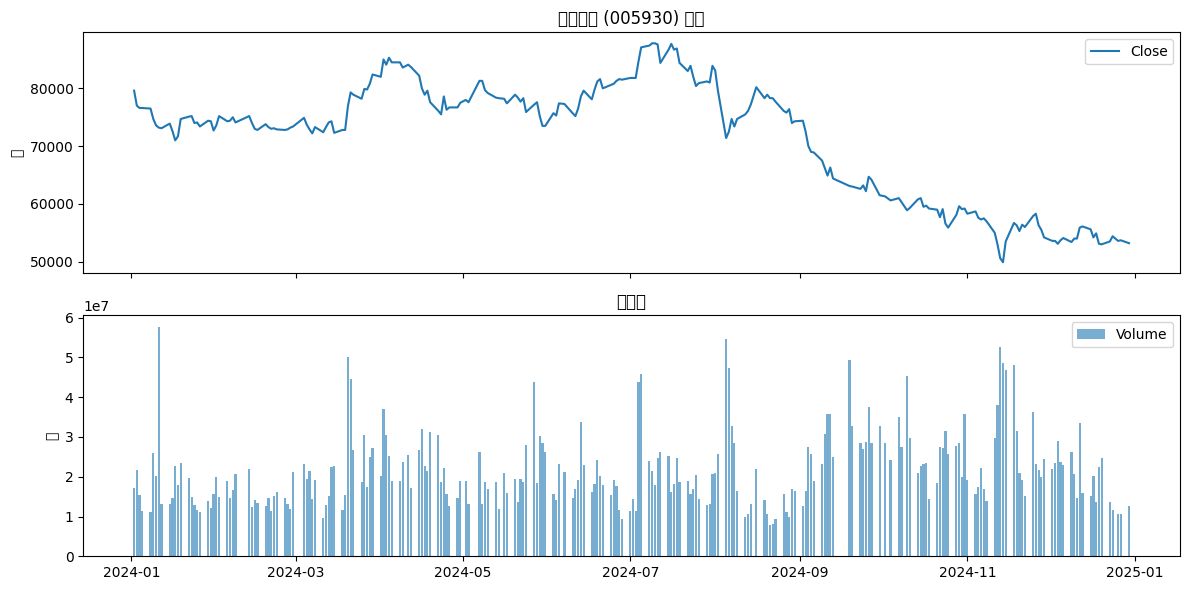

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(samsung.index, samsung['Close'], label='Close')
ax1.set_title('삼성전자 (005930) 종가')
ax1.set_ylabel('원')
ax1.legend()

ax2.bar(samsung.index, samsung['Volume'], alpha=0.6, label='Volume')
ax2.set_title('거래량')
ax2.set_ylabel('주')
ax2.legend()
plt.tight_layout()
plt.show()

## 2. 해외 주식 — Apple (AAPL)

In [4]:
aapl = fetch_stock('AAPL', '2024-01-01', '2024-12-31', market=Market.US)
print('shape:', aapl.shape)
print('schema valid:', validate_schema(aapl))
aapl.tail()

shape: (251, 5)
schema valid: True


,Open,High,Low,Close,Volume
Date,,,,,
2024-12-23,253.385834,254.261043,252.072998,253.883118,40858800
2024-12-24,254.101927,256.807136,253.903002,256.797211,23234700
2024-12-26,256.787255,258.686881,256.230300,257.612732,27237100
2024-12-27,256.429191,257.294489,251.685117,254.201370,42355300
2024-12-30,250.859609,252.122713,249.387654,250.829773,35557500


/tmp/ipykernel_43147/2046321158.py:10: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/2046321158.py:10: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/2046321158.py:10: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/2046321158.py:10: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43147/2046321158.py:10: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/hong/workspace/smart-stock-app/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hong/workspace/smart-stock-app/.ven

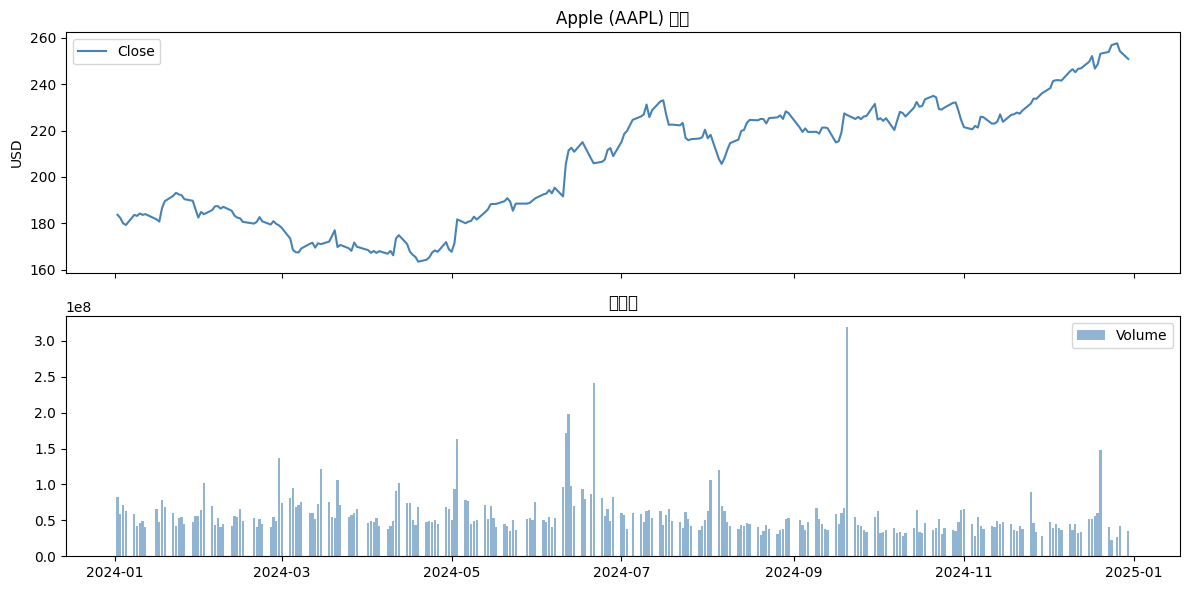

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(aapl.index, aapl['Close'], color='steelblue', label='Close')
ax1.set_title('Apple (AAPL) 종가')
ax1.set_ylabel('USD')
ax1.legend()

ax2.bar(aapl.index, aapl['Volume'], color='steelblue', alpha=0.6, label='Volume')
ax2.set_title('거래량')
ax2.legend()
plt.tight_layout()
plt.show()

## 3. 로컬 캐시 확인 (`fetch_stock_cached`)

In [ ]:
from pathlib import Path

# 최초 호출: 네트워크 조회 후 data/raw/ 에 parquet 저장
df_cached = fetch_stock_cached('005930', '2024-01-01', '2024-12-31', market=Market.KR)
print('캐시 저장 완료, shape:', df_cached.shape)

# 두 번째 호출: 캐시 파일에서 로드 (네트워크 없음)
df_cached2 = fetch_stock_cached('005930', '2024-01-01', '2024-12-31', market=Market.KR)
print('캐시 로드 완료, shape:', df_cached2.shape)

# 저장된 캐시 파일 목록
cache_files = sorted(Path('../data/raw').glob('*.parquet'))
print('캐시 파일:')
for f in cache_files:
    print(' -', f.name, f'({f.stat().st_size / 1024:.1f} KB)')